# Chapter 13 — Truth Tables and Logical Reasoning

> **Prerequisites:** ch001–ch012
>
> **You will learn:**
> - How to use truth tables to decide validity, satisfiability, and entailment
> - The three fundamental question types in logic: is it always true? ever true? does it follow?
> - How to detect tautologies and contradictions computationally
> - The limits of truth tables and when other methods are needed
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A truth table exhaustively lists all possible truth-value assignments to the variables in a formula, along with the formula's value under each assignment. It is the brute-force decision procedure for propositional logic.

Three fundamental logical questions:

1. **Valid (tautology):** Is the formula true under *every* assignment? Example: $A \lor \lnot A$ — always true.
2. **Satisfiable:** Is there *at least one* assignment making it true? Example: $A \land B$ — true when both are true.
3. **Entailment:** Do premises $P_1, \ldots, P_n$ logically entail conclusion $C$? I.e., is $P_1 \land \cdots \land P_n \Rightarrow C$ a tautology?

Truth tables answer all three questions for formulas with ≤ ~20 variables. For larger formulas, we need SAT solvers (ch012 Hard exercise) or proof systems.

**Common misconception:** If a formula is true in many cases, it is probably always true.

Not in logic. A formula that is false for even one assignment is not a tautology, no matter how many cases it passes. This is the fundamental asymmetry of universal claims.

## 2. Intuition & Mental Models

**Physical analogy:** Testing a circuit. A truth table is like systematically testing every combination of switch positions for an electrical circuit. If the light is on for every combination, the circuit always produces output. If it is on for some, the circuit is functional but conditional. This is exactly valid vs satisfiable.

**Computational analogy:** Test coverage. A tautology is a function that returns True regardless of input — 100% pass rate on every possible test. Satisfiability is a function that returns True on at least one input. Entailment is: every test case that passes the preconditions also passes the postconditions — which is what program correctness means.

Recall from ch012 *(Logic and Boolean Algebra)*: we verified identities using `are_equivalent`. That was entailment testing: we checked that two formulas have identical truth tables.

C:\Users\user\AppData\Local\Temp\ipykernel_26620\3825701969.py:45: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


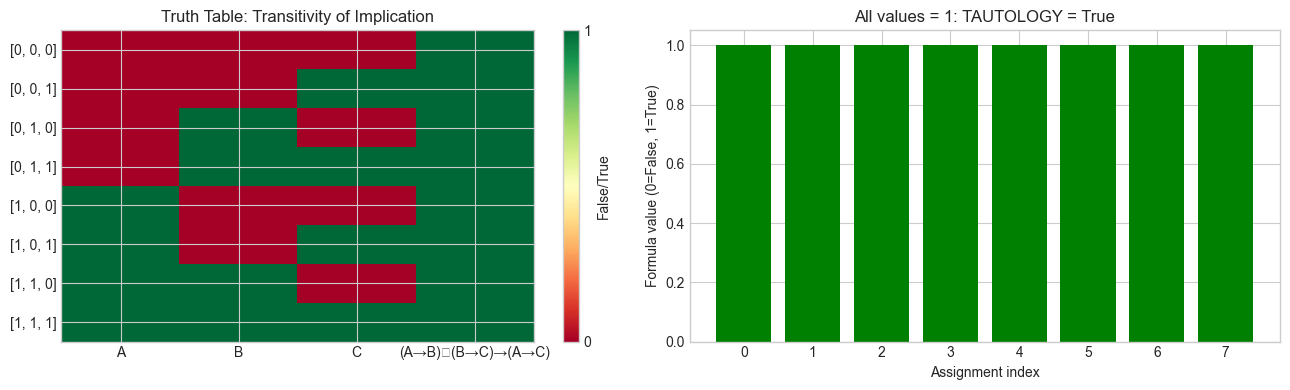

Formula is a tautology: True
(A→B) ∧ (B→C) → (A→C) is always true — implication is transitive.


In [1]:
# --- Visualization: Truth table as heatmap ---
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use('seaborn-v0_8-whitegrid')

def truth_table_matrix(formula, var_names):
    """Build truth table as a numpy matrix for visualization."""
    n = len(var_names)
    assignments = list(product([False, True], repeat=n))
    results = []
    for assign in assignments:
        env = dict(zip(var_names, assign))
        val = formula(**env)
        results.append(list(assign) + [val])
    return np.array(results, dtype=int), assignments

# Formula: (A → B) ∧ (B → C) → (A → C)  [transitivity of implication — tautology]
def transitivity(A, B, C):
    imp_ab = (not A) or B
    imp_bc = (not B) or C
    imp_ac = (not A) or C
    return not (imp_ab and imp_bc) or imp_ac

matrix, assignments = truth_table_matrix(transitivity, ['A','B','C'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: heatmap
im = axes[0].imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['A','B','C','(A→B)∧(B→C)→(A→C)'])
axes[0].set_yticks(range(len(assignments)))
axes[0].set_yticklabels([str([int(a) for a in assign]) for assign in assignments])
axes[0].set_title('Truth Table: Transitivity of Implication')
plt.colorbar(im, ax=axes[0], ticks=[0,1], label='False/True')

# Right: just the formula column to see if it's a tautology
formula_col = matrix[:, -1]
axes[1].bar(range(len(formula_col)), formula_col, color=['green' if v else 'red' for v in formula_col])
axes[1].set_xlabel('Assignment index')
axes[1].set_ylabel('Formula value (0=False, 1=True)')
axes[1].set_title(f'All values = 1: TAUTOLOGY = {bool(formula_col.all())}')

plt.tight_layout()
plt.show()

print(f"Formula is a tautology: {bool(formula_col.all())}")
print("(A→B) ∧ (B→C) → (A→C) is always true — implication is transitive.")

## 4. Mathematical Formulation

**Validity, satisfiability, and entailment — formal definitions:**

Let $\varphi$ be a propositional formula with variables $x_1, \ldots, x_n$.

- $\varphi$ is **valid** (a tautology) iff $v(\varphi) = 1$ for every truth assignment $v: \{x_1,\ldots,x_n\} \to \{0,1\}$
- $\varphi$ is **satisfiable** iff there exists $v$ such that $v(\varphi) = 1$
- $\varphi$ is **unsatisfiable** (a contradiction) iff $v(\varphi) = 0$ for every $v$
- $\Gamma \models \varphi$ (Γ **entails** $\varphi$) iff every $v$ satisfying all formulas in $\Gamma$ also satisfies $\varphi$

**Key relationships:**
- $\varphi$ is valid iff $\lnot\varphi$ is unsatisfiable
- $\Gamma \models \varphi$ iff $\Gamma \cup \{\lnot\varphi\}$ is unsatisfiable
- Every valid formula is satisfiable (but not vice versa)

The number of truth assignments for $n$ variables is $2^n$ — truth tables are exponential in $n$. For $n > 20$, brute-force is impractical.

In [4]:
# --- Implementation: Complete logical reasoning engine ---
from itertools import product

class LogicEngine:
    """
    Truth-table-based propositional logic engine.
    Answers: valid? satisfiable? entails?
    """
    def __init__(self, variables):
        self.variables = variables
        self.assignments = list(product([False, True], repeat=len(variables)))
    
    def evaluate(self, formula, assignment):
        """Evaluate formula (a Python callable) under given assignment tuple."""        
        env = dict(zip(self.variables, assignment))
        return formula(**env)
    
    def is_valid(self, formula):
        """True iff formula is true under every assignment (tautology)."""        
        return all(self.evaluate(formula, a) for a in self.assignments)
    
    def is_satisfiable(self, formula):
        """True iff some assignment satisfies the formula."""        
        return any(self.evaluate(formula, a) for a in self.assignments)
    
    def satisfying_assignments(self, formula):
        """Return all assignments that satisfy the formula."""        
        return [a for a in self.assignments if self.evaluate(formula, a)]
    
    def entails(self, premises, conclusion):
        """
        True iff every assignment satisfying all premises also satisfies conclusion.
        Equivalent to: (conjunction of premises) → conclusion is a tautology.
        """
        def combined(**env):
            return not all(p(**env) for p in premises) or conclusion(**env)
        return self.is_valid(combined)

eng = LogicEngine(['A', 'B', 'C'])

tests = [
    ('A ∨ ¬A (tautology)',         lambda A,B,C: A or not A,            'valid'),
    ('A ∧ ¬A (contradiction)',     lambda A,B,C: A and not A,           'unsat'),
    ('A ∧ B (satisfiable)',        lambda A,B,C: A and B,               'sat'),
    ('(A→B)∧(B→C)→(A→C)',         lambda A,B,C: not((not A or B) and (not B or C)) or (not A or C), 'valid'),
]

print('Logical analysis:')
for name, formula, expected in tests:
    valid = eng.is_valid(formula)
    sat   = eng.is_satisfiable(formula)
    status = 'TAUTOLOGY' if valid else ('UNSATISFIABLE' if not sat else 'SATISFIABLE')
    print(f'  {name}')
    print(f'    Status: {status}  (expected: {expected})')
    if sat and not valid:
        sats = eng.satisfying_assignments(formula)
        print(f'    Satisfying assignments: {len(sats)}/8')

print()
print('Entailment test:')
print('  Premises: {A→B, A}  Conclusion: B  (Modus Ponens)')
entails = eng.entails(
    premises=[lambda A,B,C: (not A) or B,
              lambda A,B,C: A],
    conclusion=lambda A,B,C: B
)
print(f'  Entails: {entails}  (expected: True)')

Logical analysis:
  A ∨ ¬A (tautology)
    Status: TAUTOLOGY  (expected: valid)
  A ∧ ¬A (contradiction)
    Status: UNSATISFIABLE  (expected: unsat)
  A ∧ B (satisfiable)
    Status: SATISFIABLE  (expected: sat)
    Satisfying assignments: 2/8
  (A→B)∧(B→C)→(A→C)
    Status: TAUTOLOGY  (expected: valid)

Entailment test:
  Premises: {A→B, A}  Conclusion: B  (Modus Ponens)
  Entails: True  (expected: True)


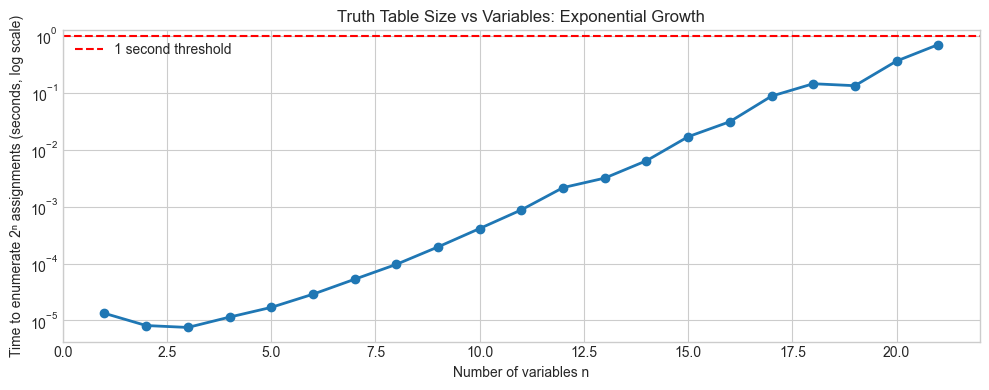

Tested up to n=21 — all under 1 second on this machine
For n=30: 2^30 = 1,073,741,824 assignments — impractical by enumeration


In [5]:
# --- Experiment: Size limits of truth tables ---
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('seaborn-v0_8-whitegrid')

N_RANGE = range(1, 22)
times = []
for n in N_RANGE:
    t0 = time.perf_counter()
    count = sum(1 for _ in product([False, True], repeat=n))  # just enumerate
    times.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(list(N_RANGE), times, 'o-', linewidth=2)
ax.axhline(1.0, color='red', linestyle='--', label='1 second threshold')
ax.set_xlabel('Number of variables n')
ax.set_ylabel('Time to enumerate 2ⁿ assignments (seconds, log scale)')
ax.set_title('Truth Table Size vs Variables: Exponential Growth')
ax.legend()
plt.tight_layout()
plt.show()

# Find crossover
crossover = next((n for n, t in zip(N_RANGE, times) if t > 1.0), None)
if crossover:
    print(f'Truth table becomes > 1 second at n = {crossover} variables ({2**crossover:,} assignments)')
else:
    print('Tested up to n=21 — all under 1 second on this machine')
print('For n=30: 2^30 = 1,073,741,824 assignments — impractical by enumeration')

## 7. Exercises

**Easy 1.** Use `LogicEngine` to determine which of these are tautologies: (a) $(A \Rightarrow B) \Leftrightarrow (\lnot B \Rightarrow \lnot A)$ (contrapositive), (b) $(A \Rightarrow B) \Rightarrow A$, (c) $A \Rightarrow (B \Rightarrow A)$. *(Expected: (a) tautology, (b) not, (c) tautology)*

**Easy 2.** Find all satisfying assignments for the formula $(A \lor \lnot B) \land (\lnot A \lor C) \land (B \lor \lnot C)$. How many are there? *(Expected: printed list)*

**Medium 1.** Prove by truth table that the following argument is valid: *Premises: "If it rains, the ground is wet." "The ground is not wet." Conclusion: "It does not rain."* (This is modus tollens: $A \Rightarrow B, \lnot B \models \lnot A$.)

**Medium 2.** A valid argument with a false conclusion must have at least one false premise. Verify this computationally: construct a valid entailment, then modify one premise to be false and show the conclusion can now be either true or false. *(Hint: use entailment check with different premise combinations)*

**Hard.** Implement **resolution theorem proving** for propositional logic: (1) convert formulas to conjunctive normal form (CNF), (2) apply the resolution rule (from $A \lor B$ and $\lnot B \lor C$, derive $A \lor C$), (3) detect unsatisfiability by deriving the empty clause. Test it on the same formulas used in `LogicEngine`. *(Challenge: measure how many resolution steps are needed vs truth table size)*

In [6]:
# --- Mini Project: Logical puzzle solver ---
# Encode a logic puzzle as propositional formulas and solve via truth tables.

# Puzzle: Three people (Alice, Bob, Carol) each made one statement.
# Exactly one of them is lying. Who is lying?
# Alice: 'Bob is honest.'
# Bob:   'Carol is lying.'
# Carol: 'Alice and Bob are both honest.'
# Variables: H_A, H_B, H_C = each person is honest (True) or lying (False)

from itertools import product

solutions = []
for H_A, H_B, H_C in product([False, True], repeat=3):
    # Alice's statement ('Bob is honest') is true iff H_A (Alice is honest)
    alice_stmt = H_B
    alice_consistent = (H_A == alice_stmt)  # honest person makes true statements
    
    # Bob's statement ('Carol is lying') is: not H_C
    bob_stmt = not H_C
    bob_consistent = (H_B == bob_stmt)
    
    # Carol's statement ('Alice and Bob are both honest'): H_A and H_B
    carol_stmt = H_A and H_B
    carol_consistent = (H_C == carol_stmt)
    
    # Constraint: exactly one liar
    exactly_one_liar = (sum([not H_A, not H_B, not H_C]) == 1)
    
    if alice_consistent and bob_consistent and carol_consistent and exactly_one_liar:
        solutions.append({'Alice': H_A, 'Bob': H_B, 'Carol': H_C})

print('Logic puzzle solutions (exactly one liar):')
for sol in solutions:
    liar = next(name for name, honest in sol.items() if not honest)
    print(f'  Alice={sol["Alice"]}, Bob={sol["Bob"]}, Carol={sol["Carol"]} → Liar: {liar}')
if not solutions:
    print('  No solution found — puzzle is inconsistent')

Logic puzzle solutions (exactly one liar):
  No solution found — puzzle is inconsistent


## 9. Chapter Summary & Connections

- Truth tables provide a complete, mechanical decision procedure for propositional logic up to ~20 variables
- The three fundamental questions are: valid (always true), satisfiable (sometimes true), entailment (follows from premises)
- Validity and unsatisfiability are duals: $\varphi$ valid iff $\lnot\varphi$ unsatisfiable
- Truth tables are exponential in the number of variables — this is why SAT is hard and why propositional theorem provers exist

**Forward:** The satisfiability problem connects to ch212 — Gradient Descent (optimization as satisfying constraints). Entailment is the logical foundation of proof (ch015). The puzzle-solver pattern scales up to constraint satisfaction in Part IX — Statistics.

**Backward:** This chapter applies ch012 *(Logic and Boolean Algebra)*'s connectives in a systematic decision procedure. The validity check is the formal version of the conjecture testing from ch004 *(Mathematical Curiosity and Exploration)*.